## Notebook 00: the CHE window

In this notebook we produce the CHE window plot from de Sá et al. (2025), Figure 1.

In [2]:
nb_id = 00

In [3]:
from time import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import astropy.units as u
import astropy.constants as ct
from scipy.optimize import fmin
from scipy.interpolate import CubicSpline
from astropy.cosmology import WMAP9

import sys
sys.path.append('..')
from src.util import (savefig_base, DATA_DIR, ROOT)
from src.star import (ToutMassRadiusRelation, grafener_m_to_l_h_burning,
                      tau_es, tau_ms, tau_gw, edd_gamma)
from src.binary import (marchant_l2_radius, SV20WindIntegrator, a_from_p, p_from_a)
from src.winds import sander2023_l_w
from src.constants import Z_SUN, t_h

plt.style.use('./plotstyle.mplstyle')

/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <

In [4]:
NB_OUTPUT_DIR = ROOT/'publication_notebooks'/'output'
FIGURE_FOLDER = NB_OUTPUT_DIR / f'nb{nb_id:02d}/plots'
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)
def savefig(*args, **kwargs): 
    savefig_base(*args, nb_id=nb_id, figure_folder=FIGURE_FOLDER, **kwargs)

In [5]:
grafener_m_to_l_h_burning(100, 0.7)

1357688.064139096

In [14]:
def get_l2of_a(m, q=1.):
    mrr = ToutMassRadiusRelation()
    def f(a):
        return np.abs((
            marchant_l2_radius(a, q).to(u.Rsun).value
            - mrr.radius(m).to(u.Rsun).value
        ))
    a = fmin(f, 10, disp=False)[0]
    return a

def get_tgw_a(m, q=1.):
    def f(a):
        p = p_from_a(a, m, q)
        return np.abs((
            tau_gw(m, p ,q).to(u.Gyr).value
            - t_h / 1e9
        ))
    a = fmin(f, 10, disp=False)[0]
    return a

def get_tes_a(m, q=1., z=Z_SUN):
    mrr = ToutMassRadiusRelation()
    def f(a):
        p = p_from_a(a, m, q)
        omega = 2 * np.pi / p.to(u.s).value
        r = mrr.radius(m).to(u.Rsun).value
        l = grafener_m_to_l_h_burning(m, x=0.7) * u.Lsun
        tes = tau_es(m, r, l, omega, z).to(u.Myr).value
        if m < 50:
            tes *= np.exp(-m/5) / np.exp(-10)
        return np.abs((
            tes
            - tau_ms(m, l, z).to(u.Myr).value
        ))
    a = fmin(f, 10, disp=False)[0]
    return a

def get_wind_tgw_a(m, q=1., z=Z_SUN, x=0.1):
    l = grafener_m_to_l_h_burning(m, x) * u.Lsun
    tms = 1.5 * tau_ms(m, l, z).to(u.yr).value
    if m > 100:
        dm = 1.
    else:
        dm = 0.1
    def f(a):
        wi = SV20WindIntegrator(m0=m, a0=a, tau_ms=tms, z=z, x=x, dm=dm)
        m_final, p_final, *_ = wi.integrate(1e9)
        return np.abs((
            tms / 1e9 + tau_gw(m_final, p_final, q).to(u.Gyr).value
            - t_h / 1e9
        ))
    a = fmin(f, 10, disp=False)[0]
    wi = SV20WindIntegrator(m0=m, a0=a, tau_ms=tms, z=z, x=x, dm=0.1)
    m_final, *_ = wi.integrate(1e9)
    return a, m_final

def get_wind_tes_a(m, q=1., z=Z_SUN, x=0.1):
    mrr = ToutMassRadiusRelation()
    l = grafener_m_to_l_h_burning(m, x) * u.Lsun
    tms = tau_ms(m, l, z).to(u.yr).value
    r = mrr.radius(m).to(u.Rsun).value
    if m > 100:
        dm = 1
    else:
        dm = 0.1
    def f(a):    
        wi = SV20WindIntegrator(m0=m, a0=a, tau_ms=tms, z=z, x=x, dm=dm)
        m_final, p_final, *_ = wi.integrate(tms)
        omega = 2 * np.pi / (p_final * u.d.to(u.s))
        r_final = mrr.radius(m_final).to(u.Rsun).value
        l_final = grafener_m_to_l_h_burning(m_final, x=x) * u.Lsun
        tes = tau_es(m_final, r_final, l_final, omega, z).to(u.Myr).value
        if m_final < 50:
            tes *= np.exp(-m_final/5) / np.exp(-10)
        return np.abs((
            tes
            - tau_ms(m_final, l_final, z).to(u.Myr).value 
        ))
    a = fmin(f, 10, disp=False)[0]
    return a

In [15]:
wi = SV20WindIntegrator(m0=300, a0=50, tau_ms=1.5e6, z=0.1*Z_SUN, x=0, dm=0.1)

wi.integrate(1e9)[1]

100.65195525105551

In [17]:
z = 0.2 * Z_SUN
x = 0

m_arr = np.logspace(1, 2.5, 5)

l2of_arr = np.zeros_like(m_arr)
tes_arr = np.zeros_like(m_arr)
tgw_arr = np.zeros_like(m_arr)
wind_tgw_arr = np.zeros_like(m_arr)
wind_tes_arr = np.zeros_like(m_arr)

for i, m in enumerate(m_arr):
    print(f'{i+1}/{len(m_arr)}: {m:.2f} Msun')
    l2of_arr[i] = get_l2of_a(m)
    tes_arr[i] = get_tes_a(m, z=z)
    tgw_arr[i] = get_tgw_a(m)
    wind_tgw_arr[i] = get_wind_tgw_a(m, z=z, x=x)[0]
    wind_tes_arr[i] = get_wind_tes_a(m, z=z, x=x)

1/5: 10.00 Msun
2/5: 23.71 Msun
3/5: 56.23 Msun
4/5: 133.35 Msun
5/5: 316.23 Msun


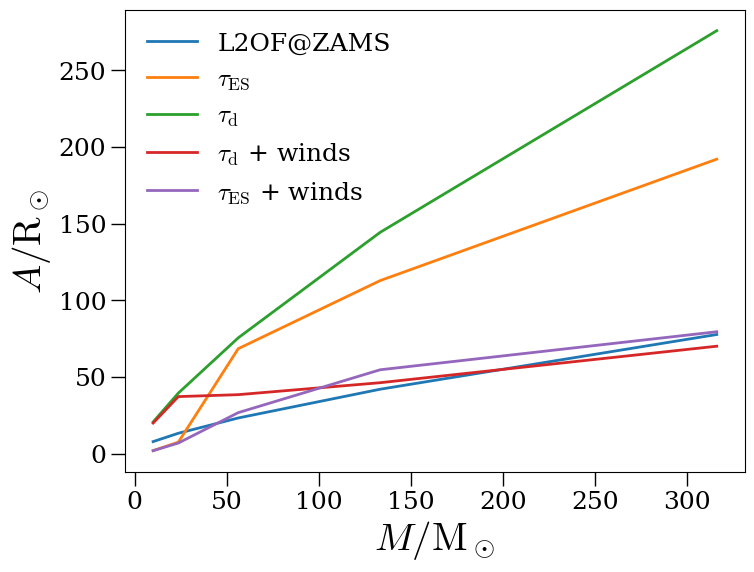

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(m_arr, l2of_arr, label='L2OF@ZAMS', color='C0')
ax.plot(m_arr, tes_arr, label='$\\tau_\\mathrm{ES}$', color='C1')
ax.plot(m_arr, tgw_arr, label='$\\tau_\\mathrm{d}$', color='C2')
ax.plot(m_arr, wind_tgw_arr, label='$\\tau_\\mathrm{d}$ + winds', color='C3')
ax.plot(m_arr, wind_tes_arr, label='$\\tau_\\mathrm{ES}$ + winds', color='C4')

ax.set_xlabel('$M/\\mathrm{M}_\\odot$')
ax.set_ylabel('$A/\\mathrm{R}_\\odot$')
ax.legend(frameon=False, fontsize=18)

From the plot above, winds restrict the CHE window significantly by decreasing its width at lower masses due to spinning-down out of CHE, and at high masses due to driving orbits to delay times longer than a Hubble time. Therefore, we include all lines but t_gw in our final plot.

In [21]:
z_arr = np.array([0.2, 0.1, 0.05]) * Z_SUN
x = 0

m_arr = np.logspace(1, 2.5, 10)

l2of_arr = np.zeros((z_arr.size, m_arr.size))
tes_arr = np.zeros((z_arr.size, m_arr.size))
tgw_arr = np.zeros((z_arr.size, m_arr.size))
wind_tgw_arr = np.zeros((z_arr.size, m_arr.size))
wind_tes_arr = np.zeros((z_arr.size, m_arr.size))
m_final_arr = np.zeros((z_arr.size, m_arr.size))

for i, z in enumerate(z_arr):
    print(f'{i+1}/{len(z_arr)}: {z:.2f} Zsun')
    for j, m in enumerate(m_arr):
        z = z_arr[i]
        print(f'{j+1}/{len(m_arr)}: {m:.2f} Msun')
        l2of_arr[i, j] = get_l2of_a(m)
        tes_arr[i, j] = get_tes_a(m, z=z)
        tgw_arr[i, j] = get_tgw_a(m)
        wind_tgw_arr[i, j], m_final_arr[i, j] = get_wind_tgw_a(m, z=z, x=x)
        wind_tes_arr[i, j] = get_wind_tes_a(m, z=z, x=x)

1/3: 0.00 Zsun
1/10: 10.00 Msun


/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/astropy/units/quantity.py:611: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


2/10: 14.68 Msun
3/10: 21.54 Msun


4/10: 31.62 Msun
5/10: 46.42 Msun
6/10: 68.13 Msun
7/10: 100.00 Msun
8/10: 146.78 Msun
9/10: 215.44 Msun
10/10: 316.23 Msun
2/3: 0.00 Zsun
1/10: 10.00 Msun
2/10: 14.68 Msun
3/10: 21.54 Msun
4/10: 31.62 Msun
5/10: 46.42 Msun
6/10: 68.13 Msun
7/10: 100.00 Msun
8/10: 146.78 Msun
9/10: 215.44 Msun
10/10: 316.23 Msun
3/3: 0.00 Zsun
1/10: 10.00 Msun
2/10: 14.68 Msun
3/10: 21.54 Msun
4/10: 31.62 Msun
5/10: 46.42 Msun
6/10: 68.13 Msun
7/10: 100.00 Msun
8/10: 146.78 Msun
9/10: 215.44 Msun
10/10: 316.23 Msun


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


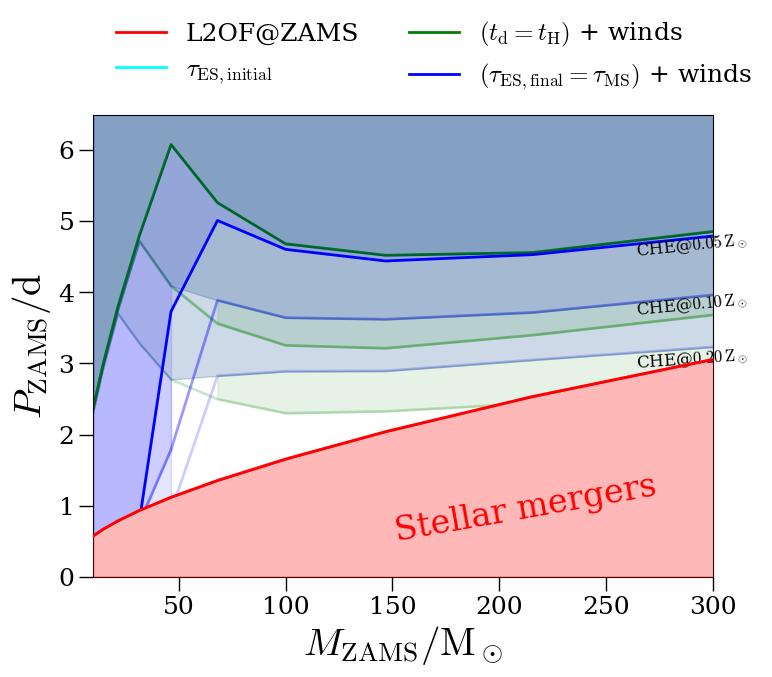

In [40]:
x_min = 10
x_max = 300
y_min = 0
y_max = 6.5
figsize = (8, 6)
fill_alpha = 0.1
save = True
fname = 'che_window'

l2of_c = 'red'
tes_c = 'cyan'
wind_tgw_c = 'green'
wind_tes_c = 'blue'

fig, ax = plt.subplots(figsize=figsize)
scale_ratio = (y_max - y_min) / (x_max - x_min)
aspect_ratio = figsize[1] / figsize[0]

x = m_arr
alpha_arr = [0.2, 0.4, 1.]
for i, z in enumerate(z_arr):
    if i != 2:
        #continue
        pass
    a = alpha_arr[i]
    # draw window boundaries
    y = p_from_a(l2of_arr[i], m_arr, q=1.)
    ax.plot(x, y, color=l2of_c, alpha=a, zorder=4)

    # t_es=t_ms at ZAMS, no wind spin-down
    #y = p_from_a(tes_arr[i], m_arr, q=1.)
    #ax.plot(x, y, color=tes_c, alpha=a)

    y = p_from_a(wind_tgw_arr[i], m_arr, q=1.)
    ax.plot(x, y, color=wind_tgw_c, alpha=a, zorder=1)

    y = p_from_a(wind_tes_arr[i], m_arr, q=1.)
    ax.plot(x, y, color=wind_tes_c, alpha=a, zorder=1)

    # darken outside window
    if i < 3:
        # this section of code is used to darken everything above the window equally
        #window_upper_p_boundary = np.max([l2of_arr[i], np.min([wind_tes_arr[i], wind_tgw_arr[i]], axis=0)], axis=0)
        #window_upper_p_boundary = p_from_a(window_upper_p_boundary, m_arr, q=1.).to(u.d).value
        #window_lower_p_boundary = p_from_a(l2of_arr[i], m_arr, q=1.).to(u.d).value
        #window_min_i = np.where(window_upper_p_boundary > window_lower_p_boundary)[0][0] - 1
        #window_max_i = np.where(window_upper_p_boundary > window_lower_p_boundary)[0][-1] + 1
        
        # this section of code distinguishes between non-CHE with or without merger
        ## che, non-merger
        y0 = p_from_a(l2of_arr[i], m_arr, q=1.).to(u.d).value
        y1 = p_from_a(wind_tes_arr[i], m_arr, q=1.).to(u.d).value
        y2 = p_from_a(wind_tgw_arr[i], m_arr, q=1.).to(u.d).value
        
        # non-che, merger
        min_i, max_i = np.where(y2 > y1)[0][[0, -1]]
        ax.fill_between(
            x[min_i:max_i+1],
            y1[min_i:max_i+1],
            y2[min_i:max_i+1],
            color=wind_tes_c, alpha=fill_alpha
        )
        
        # che, non-merger
        try:
            min_i, max_i = np.where(y1 > y2)[0][[0, -1]]
        except IndexError:
            min_i, max_i = 0, 0
        ax.fill_between(
            x[min_i:max_i+1],
            y1[min_i:max_i+1],
            y2[min_i:max_i+1],
            color=wind_tgw_c, alpha=fill_alpha
        )
        
        # non-che-non-merger
        min_y = np.max([y1, y2], axis=0)
        ax.fill_between(
            x,
            min_y,
            np.ones_like(min_y) * y_max,
            color=wind_tgw_c, alpha=fill_alpha
        )
        ax.fill_between(
            x,
            min_y,
            np.ones_like(min_y) * y_max,
            color=wind_tes_c, alpha=fill_alpha
        )

        ## stellar mergers
        ### plot a white bg in the L2OF@ZAMS region to hide the rest
        ax.fill_between(
            x,
            np.zeros_like(y0),
            y0,
            color='w', alpha=1, zorder=2
        )
        ax.fill_between(
            x,
            np.zeros_like(y0),
            y0,
            color=l2of_c, alpha=fill_alpha, zorder=3
        )
        
    # metallicity label
    y = p_from_a(wind_tes_arr[i], m_arr, q=1.).to(u.d).value
    loc_i = np.where(y > p_from_a(l2of_arr[i], m_arr, q=1.).to(u.d).value)[0][-1]
    loc_x = x[loc_i]
    loc_y = y[loc_i]
    ax.scatter(loc_x, loc_y, color='k', s=50, zorder=10)
    rotation = np.degrees(np.arctan(
        (loc_y - y[loc_i-1]) / (loc_x - x[loc_i-1]) / scale_ratio * aspect_ratio
    ))
    ax.text(
        loc_x,
        loc_y-0.4,
        f'CHE@${z/Z_SUN:.2f}\\,\\mathrm{{Z}}_\\odot$',
        rotation=rotation,
        ha='right',
        va='bottom',
        fontsize=12,
        transform=ax.transData
    )

#ax.text(90, 3, 'CHE window', rotation=-15, ha='center', va='center', fontsize=18, transform=ax.transData)

ax.set_xlabel('$M_\\mathrm{ZAMS}/\\mathrm{M}_\\odot$')
ax.set_ylabel('$P_\\mathrm{ZAMS}/\\mathrm{d}$')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

handles = []
handles.append(
    ax.plot([], [], label='L2OF@ZAMS', color=l2of_c, alpha=1)[0]
)
handles.append(
    ax.plot([], [], label='$\\tau_\\mathrm{ES,initial}$', color=tes_c, alpha=1)[0]
)
handles.append(
    ax.plot([], [], label='$(t_\\mathrm{d}=t_\\mathrm{H})$ + winds', color=wind_tgw_c, alpha=1)[0]
)
handles.append(
    ax.plot([], [], label='$(\\tau_\\mathrm{ES,final}=\\tau_\\mathrm{MS})$ + winds', color=wind_tes_c, alpha=1)[0]
)

#for i, z in enumerate(z_arr):
#    a = alpha_arr[i]
#    handles.append(
#        Line2D([], [], color='k', alpha=a, label=f'{z/Z_SUN:.3f} Z$_\\odot$')
#    )

ax.text(150, 0.4, 'Stellar mergers', ha='left', va='bottom', rotation=10, color=l2of_c, fontsize=24, transform=ax.transData)

ax.legend(handles=handles, frameon=False, loc='lower left', bbox_to_anchor=(0, 1), ncol=2, fontsize=18)

savefig(fig, fname)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


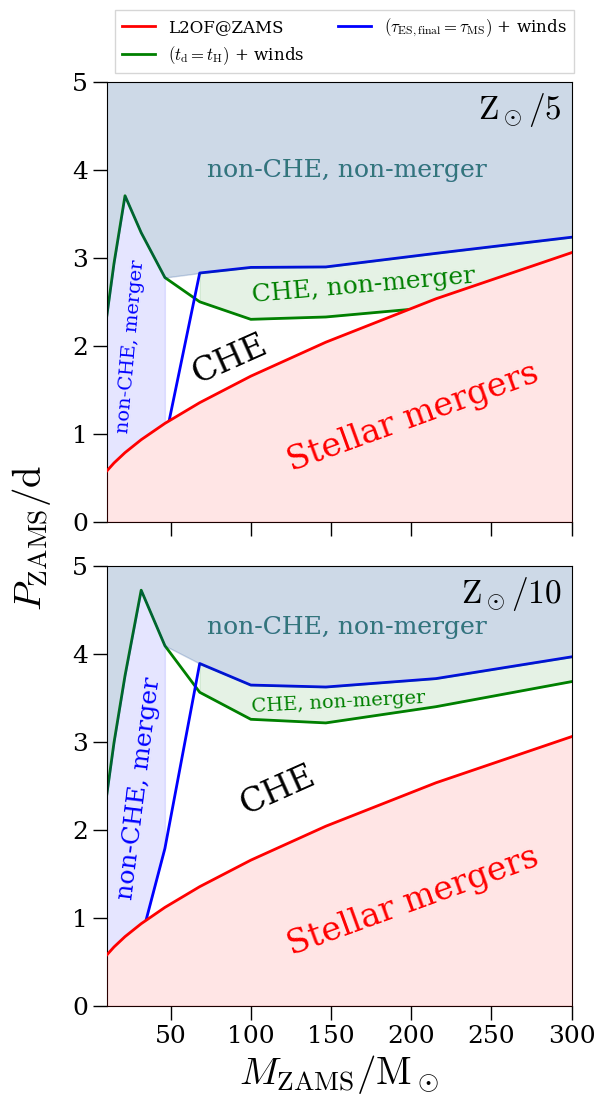

In [112]:
x_min = 10
x_max = 300
y_min = 0
y_max = 5.
figsize = (6, 12)
fill_alpha = 0.1
save = True
fname = 'che_window'

l2of_c = 'red'
tes_c = 'cyan'
wind_tgw_c = 'green'
wind_tes_c = 'blue'

fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.1)
scale_ratio = (y_max - y_min) / (x_max - x_min)
aspect_ratio = figsize[1] / figsize[0]

x = m_arr
alpha_arr = [1., 1.]
for i, z in enumerate(z_arr[:-1]):
    ax = axes[i]
    if i != 2:
        #continue
        pass
    a = alpha_arr[i]
    # draw window boundaries
    y = p_from_a(l2of_arr[i], m_arr, q=1.)
    ax.plot(x, y, color=l2of_c, alpha=a, zorder=4)

    # t_es=t_ms at ZAMS, no wind spin-down
    #y = p_from_a(tes_arr[i], m_arr, q=1.)
    #ax.plot(x, y, color=tes_c, alpha=a)

    y = p_from_a(wind_tgw_arr[i], m_arr, q=1.)
    ax.plot(x, y, color=wind_tgw_c, alpha=a, zorder=1)

    y = p_from_a(wind_tes_arr[i], m_arr, q=1.)
    ax.plot(x, y, color=wind_tes_c, alpha=a, zorder=1)

    # darken outside window
    if i < 3:
        # this section of code is used to darken everything above the window equally
        #window_upper_p_boundary = np.max([l2of_arr[i], np.min([wind_tes_arr[i], wind_tgw_arr[i]], axis=0)], axis=0)
        #window_upper_p_boundary = p_from_a(window_upper_p_boundary, m_arr, q=1.).to(u.d).value
        #window_lower_p_boundary = p_from_a(l2of_arr[i], m_arr, q=1.).to(u.d).value
        #window_min_i = np.where(window_upper_p_boundary > window_lower_p_boundary)[0][0] - 1
        #window_max_i = np.where(window_upper_p_boundary > window_lower_p_boundary)[0][-1] + 1
        
        # this section of code distinguishes between non-CHE with or without merger
        ## che, non-merger
        y0 = p_from_a(l2of_arr[i], m_arr, q=1.).to(u.d).value
        y1 = p_from_a(wind_tes_arr[i], m_arr, q=1.).to(u.d).value
        y2 = p_from_a(wind_tgw_arr[i], m_arr, q=1.).to(u.d).value
        
        # non-che, merger
        min_i, max_i = np.where(y2 > y1)[0][[0, -1]]
        ax.fill_between(
            x[min_i:max_i+1],
            y1[min_i:max_i+1],
            y2[min_i:max_i+1],
            color=wind_tes_c, alpha=fill_alpha
        )
        
        # che, non-merger
        try:
            min_i, max_i = np.where(y1 > y2)[0][[0, -1]]
        except IndexError:
            min_i, max_i = 0, 0
        ax.fill_between(
            x[min_i:max_i+1],
            y1[min_i:max_i+1],
            y2[min_i:max_i+1],
            color=wind_tgw_c, alpha=fill_alpha
        )
        
        # non-che-non-merger
        min_y = np.max([y1, y2], axis=0)
        ax.fill_between(
            x,
            min_y,
            np.ones_like(min_y) * y_max,
            color=wind_tgw_c, alpha=fill_alpha
        )
        ax.fill_between(
            x,
            min_y,
            np.ones_like(min_y) * y_max,
            color=wind_tes_c, alpha=fill_alpha
        )

        ## stellar mergers
        ### plot a white bg in the L2OF@ZAMS region to hide the rest
        ax.fill_between(
            x,
            np.zeros_like(y0),
            y0,
            color='w', alpha=1, zorder=2
        )
        ax.fill_between(
            x,
            np.zeros_like(y0),
            y0,
            color=l2of_c, alpha=fill_alpha, zorder=3
        )
        
    # metallicity label
    #y = p_from_a(wind_tes_arr[i], m_arr, q=1.).to(u.d).value
    #loc_i = np.where(y > p_from_a(l2of_arr[i], m_arr, q=1.).to(u.d).value)[0][-1]
    #loc_x = x[loc_i]
    #loc_y = y[loc_i]
    #ax.scatter(loc_x, loc_y, color='k', s=50, zorder=10)
    #rotation = np.degrees(np.arctan(
    #    (loc_y - y[loc_i-1]) / (loc_x - x[loc_i-1]) / scale_ratio * aspect_ratio
    #))
    #ax.text(
    #    loc_x,
    #    loc_y-0.4,
    #    f'CHE@${z/Z_SUN:.2f}\\,\\mathrm{{Z}}_\\odot$',
    #    rotation=rotation,
    #    ha='right',
    #    va='bottom',
    #    fontsize=12,
    #    transform=ax.transData
    #)
    ax.text(0.98, 0.98, f'$\\mathrm{{Z}}_\\odot/{Z_SUN/z:.0f}$', ha='right', va='top', fontsize=24, transform=ax.transAxes)
    ax.text(120, 0.5, 'Stellar mergers', ha='left', va='bottom', rotation=20, color=l2of_c, fontsize=24, transform=ax.transData)
#ax.text(90, 3, 'CHE window', rotation=-15, ha='center', va='center', fontsize=18, transform=ax.transData)

axes[0].text(60, 1.5, 'CHE', rotation=24, ha='left', va='bottom', fontsize=24, transform=axes[0].transData)
axes[1].text(90, 2.1, 'CHE', rotation=24, ha='left', va='bottom', fontsize=24, transform=axes[1].transData)

axes[0].text(100, 2.45, 'CHE, non-merger', rotation=5, ha='left', va='bottom', fontsize=18, color=wind_tgw_c, transform=axes[0].transData)
axes[1].text(100, 3.3, 'CHE, non-merger', rotation=3, ha='left', va='bottom', fontsize=14, color=wind_tgw_c, transform=axes[1].transData)

axes[0].text(15, 1., 'non-CHE, merger', rotation=85, ha='left', va='bottom', fontsize=14, color=wind_tes_c, transform=axes[0].transData)
axes[1].text(15, 1.2, 'non-CHE, merger', rotation=83, ha='left', va='bottom', fontsize=18, color=wind_tes_c, transform=axes[1].transData)

axes[0].text(160, 4., 'non-CHE, non-merger', rotation=0, ha='center', va='center', fontsize=18, color=wind_tes_c, alpha=0.5, transform=axes[0].transData)
axes[0].text(160, 4., 'non-CHE, non-merger', rotation=0, ha='center', va='center', fontsize=18, color=wind_tgw_c, alpha=0.5, transform=axes[0].transData)

axes[1].text(160, 4.3, 'non-CHE, non-merger', rotation=0, ha='center', va='center', fontsize=18, color=wind_tes_c, alpha=0.5, transform=axes[1].transData)
axes[1].text(160, 4.3, 'non-CHE, non-merger', rotation=0, ha='center', va='center', fontsize=18, color=wind_tgw_c, alpha=0.5, transform=axes[1].transData)

axes[1].set_xlabel('$M_\\mathrm{ZAMS}/\\mathrm{M}_\\odot$')
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)
fig.text(0, 0.5, '$P_\\mathrm{ZAMS}/\\mathrm{d}$', rotation=90, ha='center', va='center')

ax = axes[0]
handles = []
handles.append(
    ax.plot([], [], label='L2OF@ZAMS', color=l2of_c, alpha=1)[0]
)
handles.append(
    ax.plot([], [], label='$(t_\\mathrm{d}=t_\\mathrm{H})$ + winds', color=wind_tgw_c, alpha=1)[0]
)
handles.append(
    ax.plot([], [], label='$(\\tau_\\mathrm{ES,final}=\\tau_\\mathrm{MS})$ + winds', color=wind_tes_c, alpha=1)[0]
)

#for i, z in enumerate(z_arr):
#    a = alpha_arr[i]
#    handles.append(
#        Line2D([], [], color='k', alpha=a, label=f'{z/Z_SUN:.3f} Z$_\\odot$')
#    )



ax.legend(handles=handles, frameon=True, fancybox=False, loc='lower left', bbox_to_anchor=(0, 1.), ncol=2, fontsize=12)

savefig(fig, fname)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


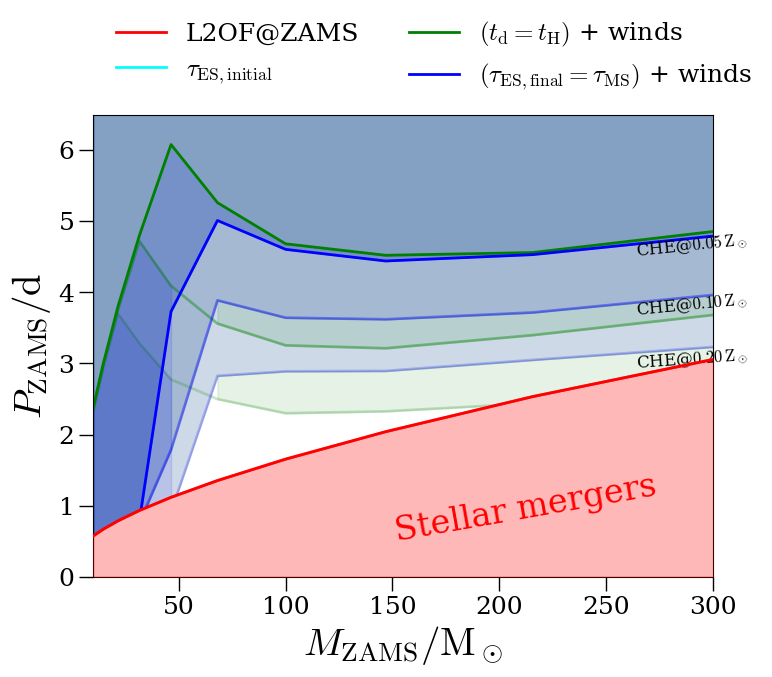

In [ ]:
x_min = 10
x_max = 300
y_min = 0
y_max = 6.5
figsize = (8, 6)
fill_alpha = 0.1
save = True
fname = 'che_window'

l2of_c = 'red'
tes_c = 'cyan'
wind_tgw_c = 'green'
wind_tes_c = 'blue'

fig, ax = plt.subplots(figsize=figsize)
scale_ratio = (y_max - y_min) / (x_max - x_min)
aspect_ratio = figsize[1] / figsize[0]

x = m_arr
alpha_arr = [0.2, 0.4, 1.]
for i, z in enumerate(z_arr):
    if i != 2:
        #continue
        pass
    a = alpha_arr[i]
    # draw window boundaries
    y = p_from_a(l2of_arr[i], m_arr, q=1.)
    ax.plot(x, y, color=l2of_c, alpha=a, zorder=4)

    # t_es=t_ms at ZAMS, no wind spin-down
    #y = p_from_a(tes_arr[i], m_arr, q=1.)
    #ax.plot(x, y, color=tes_c, alpha=a)

    y = p_from_a(wind_tgw_arr[i], m_arr, q=1.)
    ax.plot(x, y, color=wind_tgw_c, alpha=a)

    y = p_from_a(wind_tes_arr[i], m_arr, q=1.)
    ax.plot(x, y, color=wind_tes_c, alpha=a)

    # darken outside window
    if i < 3:
        # this section of code is used to darken everything above the window equally
        #window_upper_p_boundary = np.max([l2of_arr[i], np.min([wind_tes_arr[i], wind_tgw_arr[i]], axis=0)], axis=0)
        #window_upper_p_boundary = p_from_a(window_upper_p_boundary, m_arr, q=1.).to(u.d).value
        #window_lower_p_boundary = p_from_a(l2of_arr[i], m_arr, q=1.).to(u.d).value
        #window_min_i = np.where(window_upper_p_boundary > window_lower_p_boundary)[0][0] - 1
        #window_max_i = np.where(window_upper_p_boundary > window_lower_p_boundary)[0][-1] + 1
        
        # this section of code distinguishes between non-CHE with or without merger
        ## che, non-merger
        y0 = p_from_a(l2of_arr[i], m_arr, q=1.).to(u.d).value
        y1 = p_from_a(wind_tes_arr[i], m_arr, q=1.).to(u.d).value
        y2 = p_from_a(wind_tgw_arr[i], m_arr, q=1.).to(u.d).value
        
        # non-che, merger
        min_i, max_i = np.where(y2 > y1)[0][[0, -1]]
        ax.fill_between(
            x[min_i:max_i+1],
            y1[min_i:max_i+1],
            y2[min_i:max_i+1],
            color=wind_tes_c, alpha=fill_alpha
        )
        
        # che, non-merger
        try:
            min_i, max_i = np.where(y1 > y2)[0][[0, -1]]
        except IndexError:
            min_i, max_i = 0, 0
        ax.fill_between(
            x[min_i:max_i+1],
            y1[min_i:max_i+1],
            y2[min_i:max_i+1],
            color=wind_tgw_c, alpha=fill_alpha
        )
        
        # non-che-non-merger
        min_y = np.max([y1, y1], axis=0)
        ax.fill_between(
            x,
            min_y,
            np.ones_like(min_y) * y_max,
            color=wind_tgw_c, alpha=fill_alpha, zorder=1
        )
        ax.fill_between(
            x,
            min_y,
            np.ones_like(min_y) * y_max,
            color=wind_tes_c, alpha=fill_alpha, zorder=1
        )

        ## stellar mergers
        ### plot a white bg in the L2OF@ZAMS region to hide the rest
        ax.fill_between(
            x,
            np.zeros_like(y0),
            y0,
            color='w', alpha=1, zorder=2
        )
        ax.fill_between(
            x,
            np.zeros_like(y0),
            y0,
            color=l2of_c, alpha=fill_alpha, zorder=3
        )
        
    # metallicity label
    y = p_from_a(wind_tes_arr[i], m_arr, q=1.).to(u.d).value
    loc_i = np.where(y > p_from_a(l2of_arr[i], m_arr, q=1.).to(u.d).value)[0][-1]
    loc_x = x[loc_i]
    loc_y = y[loc_i]
    ax.scatter(loc_x, loc_y, color='k', s=50, zorder=10)
    rotation = np.degrees(np.arctan(
        (loc_y - y[loc_i-1]) / (loc_x - x[loc_i-1]) / scale_ratio * aspect_ratio
    ))
    ax.text(
        loc_x,
        loc_y-0.4,
        f'CHE@${z/Z_SUN:.2f}\\,\\mathrm{{Z}}_\\odot$',
        rotation=rotation,
        ha='right',
        va='bottom',
        fontsize=12,
        transform=ax.transData
    )

#ax.text(90, 3, 'CHE window', rotation=-15, ha='center', va='center', fontsize=18, transform=ax.transData)

ax.set_xlabel('$M_\\mathrm{ZAMS}/\\mathrm{M}_\\odot$')
ax.set_ylabel('$P_\\mathrm{ZAMS}/\\mathrm{d}$')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

handles = []
handles.append(
    ax.plot([], [], label='L2OF@ZAMS', color=l2of_c, alpha=1)[0]
)
handles.append(
    ax.plot([], [], label='$\\tau_\\mathrm{ES,initial}$', color=tes_c, alpha=1)[0]
)
handles.append(
    ax.plot([], [], label='$(t_\\mathrm{d}=t_\\mathrm{H})$ + winds', color=wind_tgw_c, alpha=1)[0]
)
handles.append(
    ax.plot([], [], label='$(\\tau_\\mathrm{ES,final}=\\tau_\\mathrm{MS})$ + winds', color=wind_tes_c, alpha=1)[0]
)

#for i, z in enumerate(z_arr):
#    a = alpha_arr[i]
#    handles.append(
#        Line2D([], [], color='k', alpha=a, label=f'{z/Z_SUN:.3f} Z$_\\odot$')
#    )

ax.text(150, 0.4, 'Stellar mergers', ha='left', va='bottom', rotation=10, color=l2of_c, fontsize=24, transform=ax.transData)

ax.legend(handles=handles, frameon=False, loc='lower left', bbox_to_anchor=(0, 1), ncol=2, fontsize=18)

savefig(fig, fname)